In [ ]:
# Run for Clean Start

import sys
import shutil
from pathlib import Path

# Remove all cached modules
for mod in list(sys.modules.keys()):
    if any(
        name in mod
        for name in [
            "data_loader",
            "vit_model",
            "field_vocab",
            "trainer",
            "conf_scoring",
        ]
    ):
        del sys.modules[mod]

# Delete all disk caches
caches = [
    "../Experiments/cord_img_cache",
    "../Experiments/img_cache",
    "../Experiments/vocab.json",
    "../Experiments/checkpoints",
    "../Experiments/temperatures.json",
    "../Experiments/thresholds.json",
    "../Experiments/review_queue.json",
    "../Experiments/test_evaluation.json",
]
for path in caches:
    p = Path(path)
    if p.is_dir():
        shutil.rmtree(p)
        print(f"Deleted dir:  {p}")
    elif p.exists():
        p.unlink()
        print(f"Deleted file: {p}")

print("\n✓ All caches cleared — restart kernel then re-run from Cell 1")

Deleted dir:  ../Experiments/cord_img_cache
Deleted dir:  ../Experiments/img_cache
Deleted dir:  ../Experiments/checkpoints

✓ All caches cleared — restart kernel then re-run from Cell 1


In [ ]:
from src.data_setup import setup_all

setup_all()

In [79]:
# Cell 1

import os
import sys
import json
import importlib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import torch

In [ ]:
# Cell 2

BASE = "../sroie-receipt-dataset/SROIE2019"
SPLITS = ["train", "test"]
IMAGE_SIZE = 224
PATCH_SIZE = 16
IN_CHANNELS = 3
EMBED_DIM = 256
SEED = 42

import sys

sys.path.append("../src")

import torch

device_str = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
device = torch.device(device_str)
print(f"Device: {device}")

Device: mps


In [ ]:
# Cell 3

# Build EDA dataframe (cached after first run)
from PIL import Image

CACHE = Path("../Experiments/eda_cache.pkl")

if CACHE.exists():
    import pickle

    df = pickle.load(open(CACHE, "rb"))
    print(f"Loaded cached dataframe ({len(df)} rows) — skipping image scan")
else:
    records = []
    for split in SPLITS:
        img_dir = os.path.join(BASE, split, "img")
        ent_dir = os.path.join(BASE, split, "entities")
        images_list = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
        entity_files = sorted(os.listdir(ent_dir))
        print(
            f"\n{split.upper()}: {len(images_list)} images | {len(entity_files)} entity files"
        )
        for img_file in images_list:
            stem = os.path.splitext(img_file)[0]
            ent_path = os.path.join(ent_dir, stem + ".txt")
            img = Image.open(os.path.join(img_dir, img_file))
            w, h = img.size
            fields = {"company": None, "date": None, "address": None, "total": None}
            if os.path.exists(ent_path):
                with open(ent_path, "r", encoding="utf-8", errors="ignore") as fh:
                    try:
                        data = json.load(fh)
                        for key in fields:
                            fields[key] = data.get(key) or None
                    except json.JSONDecodeError:
                        pass
            records.append(
                {"split": split, "file": img_file, "width": w, "height": h, **fields}
            )
    df = pd.DataFrame(records)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    import pickle

    pickle.dump(df, open(CACHE, "wb"))
    print(f"\nBuilt and cached dataframe ({len(df)} rows)")

print("── Dataset shape:", df.shape)
print(df.head(3))

Loaded cached dataframe (973 rows) — skipping image scan
── Dataset shape: (973, 8)
   split              file  width  height                          company  \
0  train  X00016469612.jpg    463    1013  BOOK TA .K (TAMAN DAYA) SDN BHD   
1  train  X00016469619.jpg    439    1004           INDAH GIFT & HOME DECO   
2  train  X00016469620.jpg    459     949        MR D.I.Y. (JOHOR) SDN BHD   

         date                                            address  total  
0  25/12/2018  NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...   9.00  
1  19/10/2018  27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...  60.30  
2    12-01-19  LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...  33.90  


In [ ]:
# Cell 4

# EDA plots — run once for the report
print("\n── Image Dimensions ──")
print(df[["width", "height"]].describe().round(1))

fields_eda = ["company", "date", "address", "total"]
completeness = df[fields_eda].notnull().mean() * 100
print("\n── Field Completeness (%) ──")
print(completeness.round(1))

all_four = df[fields_eda].notnull().all(axis=1).sum()
print(
    f"\nReceipts with ALL 4 fields: {all_four} / {len(df)} ({100*all_four/len(df):.1f}%)"
)


── Image Dimensions ──
        width  height
count   973.0   973.0
mean   1359.6  2401.2
std    1444.5  1880.1
min     435.0   605.0
25%     627.0  1400.0
50%     825.0  1697.0
75%     935.0  2167.0
max    4961.0  7016.0

── Field Completeness (%) ──
company    100.0
date       100.0
address     99.9
total       99.9
dtype: float64

Receipts with ALL 4 fields: 971 / 973 (99.8%)


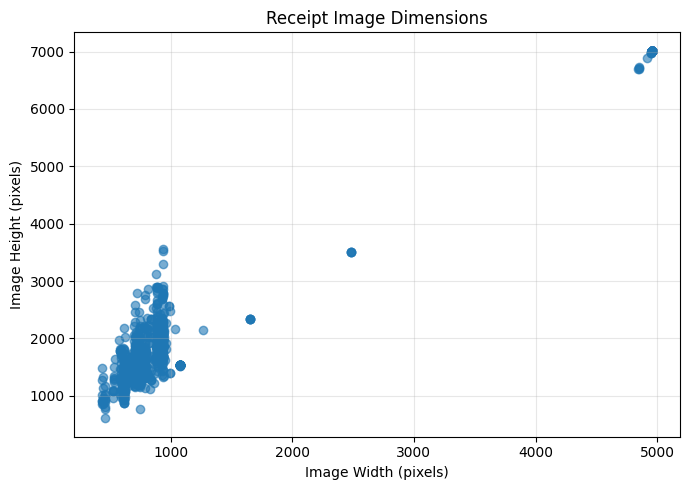

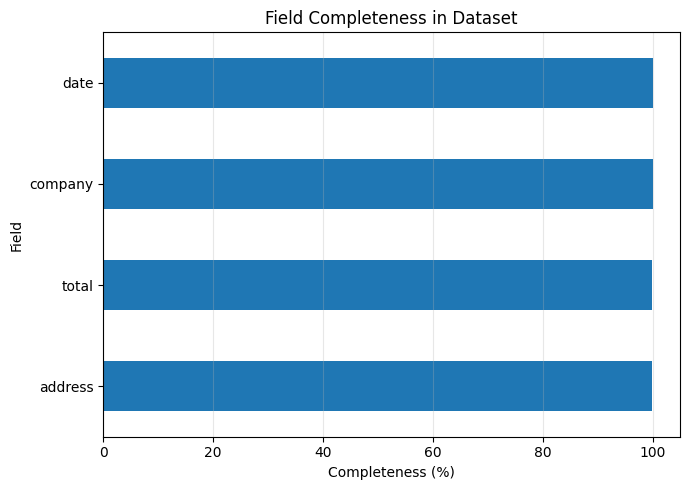

In [83]:
# Cell 4B — EDA plots

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["width"], df["height"], alpha=0.6)
ax.set_title("Receipt Image Dimensions")
ax.set_xlabel("Image Width (pixels)")
ax.set_ylabel("Image Height (pixels)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
completeness.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Field Completeness in Dataset")
ax.set_xlabel("Completeness (%)")
ax.set_ylabel("Field")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5

from sklearn.model_selection import train_test_split

df_train_full = df[df["split"] == "train"].reset_index(drop=True)
df_test = df[df["split"] == "test"].reset_index(drop=True)
df_train, df_val = train_test_split(df_train_full, test_size=0.1, random_state=SEED)

print(f"Train : {len(df_train)}")
print(f"Val   : {len(df_val)}")
print(f"Test  : {len(df_test)}")

Train : 563
Val   : 63
Test  : 347


In [ ]:
# Cell 6

# Pre-cache resized val/test images to disk (runs once, ~5 min, skips if done)
from torchvision import transforms
from tqdm import tqdm

CACHE_DIR = Path("../Experiments/img_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Only cache val and test — train uses augmentation so must stay dynamic
cache_rows = pd.concat([df_val, df_test], ignore_index=True)
skipped = 0
for _, row in tqdm(cache_rows.iterrows(), total=len(cache_rows)):
    out_path = CACHE_DIR / row["file"].replace(".jpg", ".pt")
    if out_path.exists():
        skipped += 1
        continue
    img_path = os.path.join(BASE, row["split"], "img", row["file"])
    tensor = transform(Image.open(img_path).convert("RGB"))
    torch.save(tensor, out_path)

cached = len(cache_rows) - skipped
print(f"Done. {cached} cached, {skipped} already existed")
print(f"Cache: {sum(f.stat().st_size for f in CACHE_DIR.glob('*.pt'))/1e6:.0f} MB")

100%|██████████| 410/410 [00:20<00:00, 19.60it/s]

Done. 410 cached, 0 already existed
Cache: 247 MB


In [ ]:
# Cell 7

import data_loader, importlib

importlib.reload(data_loader)
from data_loader import get_dataloaders, collate_fn

# CORD + WildReceipt (most data)
train_loader, val_loader, test_loader = get_dataloaders(
    BASE,
    batch_size=64,
    num_workers=4,
    use_cord=True,
    use_wildreceipt=True,
    wildreceipt_path="../wildreceipt",
)

images, annotations = next(iter(train_loader))
print(f"Batch shape  : {images.shape}")
print(f"num_workers  : {train_loader.num_workers}")
print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

Loading CORD dataset...
  CORD: first run — saving images to disk (runs once)...
  CORD: saved 800 train / 100 val / 100 test images
  CORD: 800 train / 100 val / 100 test
Loading WildReceipt dataset...
  WildReceipt: 1140 train / 127 val / 472 test
Total: 2503 train / 290 val / 919 test
Batch shape  : torch.Size([64, 3, 224, 224])
num_workers  : 4
Train batches: 40
Val   batches: 5


In [ ]:
# Cell 8

# Tesseract + Regex Baseline — runs once, then skips
RESULTS_PATH = Path("../Experiments/experiment1_results.json")

if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        baseline_results = json.load(f)
    print("Baseline already computed — skipping Tesseract run")
    print("\n===== EXPERIMENT 1: TESSERACT + REGEX BASELINE =====")
    for field, metrics in baseline_results.items():
        em = metrics.get("exact_match", "")
        f1 = metrics.get("f1", "")
        if isinstance(em, float):
            print(f"{field.upper():10s}  Exact Match: {em:.3f}  F1: {f1:.3f}")
else:
    from baseline import run_baseline

    test_samples = [
        {
            "image_path": os.path.join(BASE, row["split"], "img", row["file"]),
            "annotation": {
                k: row[k] or "" for k in ["company", "date", "address", "total"]
            },
        }
        for _, row in df_test.iterrows()
    ]
    baseline_results = run_baseline(test_samples)
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(RESULTS_PATH, "w") as f:
        json.dump(baseline_results, f, indent=2)
    print("\n===== EXPERIMENT 1: TESSERACT + REGEX BASELINE =====")
    for field, metrics in baseline_results.items():
        print(
            f"{field.upper():10s}  Exact Match: {metrics['exact_match']:.3f}  F1: {metrics['f1']:.3f}"
        )

Baseline already computed — skipping Tesseract run

===== EXPERIMENT 1: TESSERACT + REGEX BASELINE =====
COMPANY     Exact Match: 0.130  F1: 0.332
DATE        Exact Match: 0.706  F1: 0.708
ADDRESS     Exact Match: 0.012  F1: 0.535
TOTAL       Exact Match: 0.297  F1: 0.301
OVERALL     Exact Match: 0.286  F1: 0.469


In [ ]:
# Run only to remove caches

import sys

# Remove cached versions of both modules
for mod in ["field_vocab", "vit_model"]:
    if mod in sys.modules:
        del sys.modules[mod]

# Now re-import fresh
import field_vocab
import vit_model
print("MAX_LEN_INT" in dir(field_vocab))  # should print True

True


In [ ]:
# Cell 9

# Smoke-test model components
import vit_model

importlib.reload(vit_model)
from vit_model import (
    PatchEmbedding,
    LearnablePositionalEmbedding,
    PatchAndPositionEmbedding,
)

patch_embed = PatchEmbedding(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
)
print(patch_embed)
print(f"num_patches: {patch_embed.num_patches}")

sample_imgs, _ = next(iter(val_loader))  # val uses cache — fast
B = sample_imgs.size(0)

with torch.no_grad():
    out = patch_embed(sample_imgs)
assert out.shape == (B, patch_embed.num_patches, EMBED_DIM)

embed_layer = PatchAndPositionEmbedding(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
)
with torch.no_grad():
    out2 = embed_layer(sample_imgs)
assert out2.shape == (B, embed_layer.num_patches, EMBED_DIM)
print("✓ PatchEmbedding and PatchAndPositionEmbedding correct")

PatchEmbedding(image_size=224, patch_size=16, num_patches=196, embed_dim=256)
num_patches: 196
✓ PatchEmbedding and PatchAndPositionEmbedding correct


In [ ]:
# Cell 10
import field_vocab, importlib

importlib.reload(field_vocab)
from field_vocab import FieldVocab

VOCAB_SAVE = Path("../Experiments/vocab.json")

if VOCAB_SAVE.exists():
    vocab = FieldVocab.load(str(VOCAB_SAVE))
    print("Vocab loaded from disk — skipping rebuild")
else:
    vocab = FieldVocab.build(df_train)
    VOCAB_SAVE.parent.mkdir(parents=True, exist_ok=True)
    vocab.save(str(VOCAB_SAVE))
    print("Vocab built and saved")

for field in ["vendor", "date", "total", "address"]:
    print(f"  {field:8s}  vocab size: {vocab.size(field):4d}")

✓ Char vocab saved to ../Experiments/vocab.json
Vocab built and saved
  vendor    vocab size:   85
  date      vocab size:   85
  total     vocab size:   85
  address   vocab size:   85


In [ ]:
# Cell 11

# Instantiate Exp2 and Exp3 models
from vit_model import ReceiptViT

model_exp2 = ReceiptViT(
    vocab_sizes=vocab.vocab_sizes(),
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
    num_layers=4,
    num_heads=4,
    dropout=0.1,
)
model_exp3 = ReceiptViT(
    vocab_sizes=vocab.vocab_sizes(),
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM,
    num_layers=6,
    num_heads=8,
    dropout=0.1,
)

total2 = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total3 = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
print(f"Exp2 params: {total2:,}")
print(f"Exp3 params: {total3:,}")

Exp2 params: 4,581,972
Exp3 params: 6,161,492


In [ ]:
# Cell 12

# Train Experiment 2 — runs once, then loads checkpoint
import trainer

importlib.reload(trainer)
from trainer import train_model

CKPT_DIR2 = Path("../Experiments/checkpoints/exp2")
CKPT_FILE2 = CKPT_DIR2 / "best_model.pt"

if CKPT_FILE2.exists() and (CKPT_DIR2 / "results.json").exists():
    results_exp2 = json.load(open(CKPT_DIR2 / "results.json"))
    history_exp2 = (
        json.load(open(CKPT_DIR2 / "history.json"))
        if (CKPT_DIR2 / "history.json").exists()
        else []
    )
    model_exp2.load_state_dict(torch.load(CKPT_FILE2, map_location=device_str))
    model_exp2.to(device)
    print("Exp2 checkpoint loaded — skipping training")
else:
    results_exp2, history_exp2 = train_model(
        model=model_exp2,
        train_loader=train_loader,
        val_loader=val_loader,
        vocab=vocab,
        num_epochs=80,
        lr=1e-5,
        device_str=device_str,
        checkpoint_dir=str(CKPT_DIR2),
    )
    CKPT_DIR2.mkdir(parents=True, exist_ok=True)
    json.dump(results_exp2, open(CKPT_DIR2 / "results.json", "w"), indent=2)
    json.dump(history_exp2, open(CKPT_DIR2 / "history.json", "w"), indent=2)

print("Exp2 results:", results_exp2)

 Ep   TrLoss  tr_ven  tr_dat  tr_tot  tr_add   VaLoss  va_ven  va_dat  va_tot  va_add     s
───────────────────────────────────────────────────────────────────────────────────────────
  1   4.5409   0.000   0.003   0.016   0.000   4.4627   0.314   0.021   0.234   0.000    19s
  2   4.3877   0.000   0.003   0.009   0.000   4.2535   0.586   0.041   0.186   0.003    18s
  3   4.1383   0.077   0.008   0.006   0.000   3.9407   0.669   0.083   0.131   0.059    20s
  4   3.8325   0.485   0.056   0.001   0.017   3.5505   0.714   0.176   0.069   0.676    18s
  5   3.4142   0.632   0.197   0.002   0.360   3.0512   0.734   0.445   0.369   0.752    18s
  6   2.8858   0.684   0.437   0.215   0.684   2.4492   0.759   0.731   0.424   0.762    20s
  7   2.3249   0.732   0.693   0.409   0.726   1.9089   0.769   0.769   0.431   0.762    19s
  8   1.8290   0.760   0.762   0.437   0.757   1.8391   0.776   0.779   0.431   0.776    19s
  9   1.4885   0.771   0.773   0.457   0.773   1.3125   0.779   0.783   

In [ ]:
# Cell 13

# Train Experiment 3 — runs once, then loads checkpoint
CKPT_DIR3 = Path("../Experiments/checkpoints/exp3")
CKPT_FILE3 = CKPT_DIR3 / "best_model.pt"

if CKPT_FILE3.exists() and (CKPT_DIR3 / "results.json").exists():
    results_exp3 = json.load(open(CKPT_DIR3 / "results.json"))
    history_exp3 = (
        json.load(open(CKPT_DIR3 / "history.json"))
        if (CKPT_DIR3 / "history.json").exists()
        else []
    )
    model_exp3.load_state_dict(torch.load(CKPT_FILE3, map_location=device_str))
    model_exp3.to(device)
    print("Exp3 checkpoint loaded — skipping training")
else:
    results_exp3, history_exp3 = train_model(
        model=model_exp3,
        train_loader=train_loader,
        val_loader=val_loader,
        vocab=vocab,
        num_epochs=80,
        lr=1e-5,
        device_str=device_str,
        checkpoint_dir=str(CKPT_DIR3),
    )
    CKPT_DIR3.mkdir(parents=True, exist_ok=True)
    json.dump(results_exp3, open(CKPT_DIR3 / "results.json", "w"), indent=2)
    json.dump(history_exp3, open(CKPT_DIR3 / "history.json", "w"), indent=2)

print("Exp3 results:", results_exp3)

 Ep   TrLoss  tr_ven  tr_dat  tr_tot  tr_add   VaLoss  va_ven  va_dat  va_tot  va_add     s
───────────────────────────────────────────────────────────────────────────────────────────
  1   4.2919   0.000   0.000   0.000   0.000   4.0368   0.017   0.014   0.000   0.000    22s
  2   4.0876   0.000   0.001   0.000   0.000   3.8975   0.655   0.376   0.000   0.000    23s
  3   3.8386   0.075   0.120   0.000   0.000   3.5866   0.734   0.617   0.000   0.045    23s
  4   3.5295   0.512   0.493   0.003   0.005   3.0245   0.745   0.700   0.314   0.262    23s
  5   3.1043   0.682   0.635   0.173   0.135   2.7535   0.762   0.738   0.424   0.679    23s
  6   2.6028   0.716   0.688   0.391   0.464   2.1959   0.766   0.762   0.424   0.752    23s
  7   2.1165   0.750   0.738   0.427   0.702   1.8256   0.776   0.772   0.431   0.766    21s
  8   1.7339   0.771   0.770   0.443   0.756   1.4619   0.783   0.779   0.434   0.776    23s
  9   1.4926   0.775   0.775   0.459   0.772   1.4337   0.783   0.783   

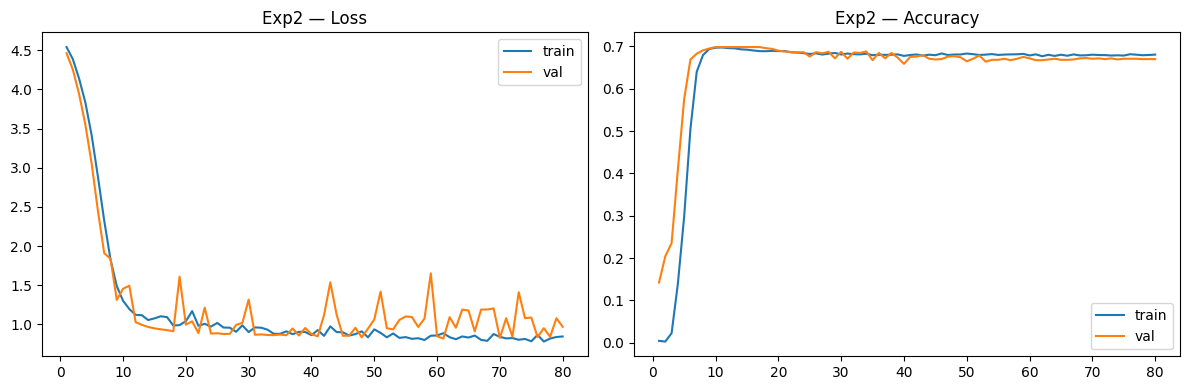


Exp2 final: {'epoch': 80.0, 'train_loss': 0.8451539175157018, 'train_acc': 0.6804834198961247, 'val_loss': 0.9690718359988312, 'val_acc': 0.6698275862068965, 'train_acc_vendor': 0.7746703955253695, 'train_acc_date': 0.7499001198561726, 'train_acc_total': 0.4306831801837795, 'train_acc_address': 0.766679984019177, 'val_acc_vendor': 0.7827586206896552, 'val_acc_date': 0.7758620689655172, 'val_acc_total': 0.33793103448275863, 'val_acc_address': 0.7827586206896552}


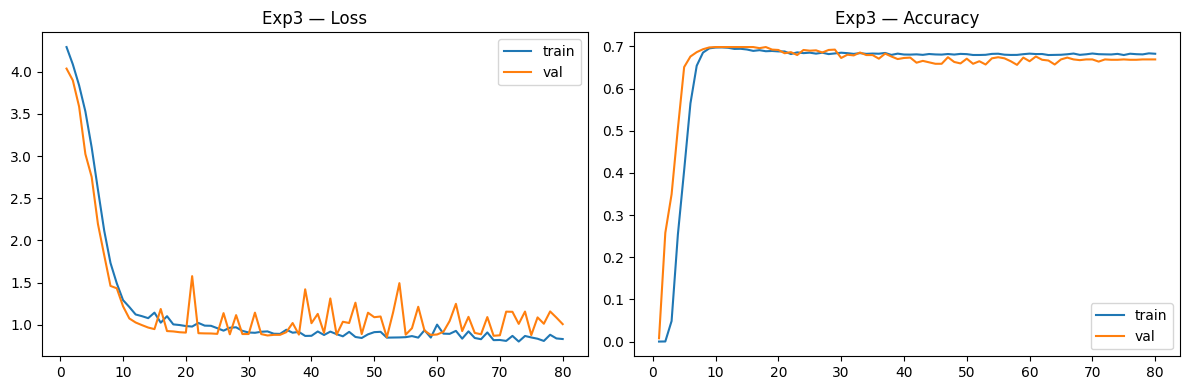


Exp3 final: {'epoch': 80.0, 'train_loss': 0.8325953210919464, 'train_acc': 0.6823811426288454, 'val_loss': 1.0090693200456684, 'val_acc': 0.6689655172413793, 'train_acc_vendor': 0.7738713543747503, 'train_acc_date': 0.7586895725129844, 'train_acc_total': 0.4274870155813024, 'train_acc_address': 0.7694766280463444, 'val_acc_vendor': 0.7827586206896552, 'val_acc_date': 0.7827586206896552, 'val_acc_total': 0.3275862068965517, 'val_acc_address': 0.7827586206896552}


In [ ]:
# Cell 14

# Training curves
for exp, history in [("Exp2", history_exp2), ("Exp3", history_exp3)]:
    if not history:
        print(f"{exp}: no history")
        continue
    df_hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="train")
    axes[0].plot(df_hist["epoch"], df_hist["val_loss"], label="val")
    axes[0].set_title(f"{exp} — Loss")
    axes[0].legend()
    axes[1].plot(df_hist["epoch"], df_hist["train_acc"], label="train")
    axes[1].plot(df_hist["epoch"], df_hist["val_acc"], label="val")
    axes[1].set_title(f"{exp} — Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"../Experiments/{exp}_curves.png", dpi=120)
    plt.show()
    print(f"\n{exp} final:", df_hist.iloc[-1].to_dict())

In [ ]:
# Cell 15 — Smoke-test PatchEmbedding with a real batch (uses temp loader, doesn't overwrite train_loader)
from data_loader import get_dataloaders

_smoke_loader, _, _ = get_dataloaders(
    BASE, batch_size=4
)  # temp var, won't overwrite train_loader

images, annotations = next(iter(_smoke_loader))
print(f"Input  shape : {images.shape}")

with torch.no_grad():
    embeddings = patch_embed(images)

print(f"Output shape : {embeddings.shape}")
assert embeddings.shape == (4, patch_embed.num_patches, EMBED_DIM), "Shape mismatch!"
print("\n✓ PatchEmbedding forward pass correct")

Total: 563 train / 63 val / 347 test
Input  shape : torch.Size([4, 3, 224, 224])
Output shape : torch.Size([4, 196, 256])

✓ PatchEmbedding forward pass correct


In [ ]:
# Cell 16

from baseline import token_f1
from field_vocab import FIELDS, _DF_COL, normalize_label


def evaluate_token_f1(model, loader, vocab, device):
    model = model.to(device)
    model.eval()
    field_f1 = {f: [] for f in FIELDS}
    with torch.no_grad():
        for images, annotations in loader:
            images = images.to(device)
            logits = model(images)
            for f in FIELDS:
                col = _DF_COL[f]
                preds = logits[f].argmax(dim=-1).cpu().tolist()
                for pred_idx, ann in zip(preds, annotations):
                    pred_str = vocab.decode(f, pred_idx)
                    gt_raw = ann.get(col, "") or ""
                    gt_str = normalize_label(f, gt_raw)
                    if pred_str == "<UNK>":
                        field_f1[f].append(0.0)
                    else:
                        field_f1[f].append(token_f1(pred_str, gt_str))
    return {f: round(sum(v) / len(v), 4) for f, v in field_f1.items()}


print("── Exp2 Token F1 (val) ──")
f1_exp2 = evaluate_token_f1(model_exp2, val_loader, vocab, device)
for f, s in f1_exp2.items():
    print(f"  {f:8s}: {s:.4f}")

print("\n── Exp3 Token F1 (val) ──")
f1_exp3 = evaluate_token_f1(model_exp3, val_loader, vocab, device)
for f, s in f1_exp3.items():
    print(f"  {f:8s}: {s:.4f}")

── Exp2 Token F1 (val) ──
  vendor  : 0.7828
  date    : 0.7828
  total   : 0.4448
  address : 0.7828

── Exp3 Token F1 (val) ──
  vendor  : 0.7828
  date    : 0.7828
  total   : 0.4448
  address : 0.7828


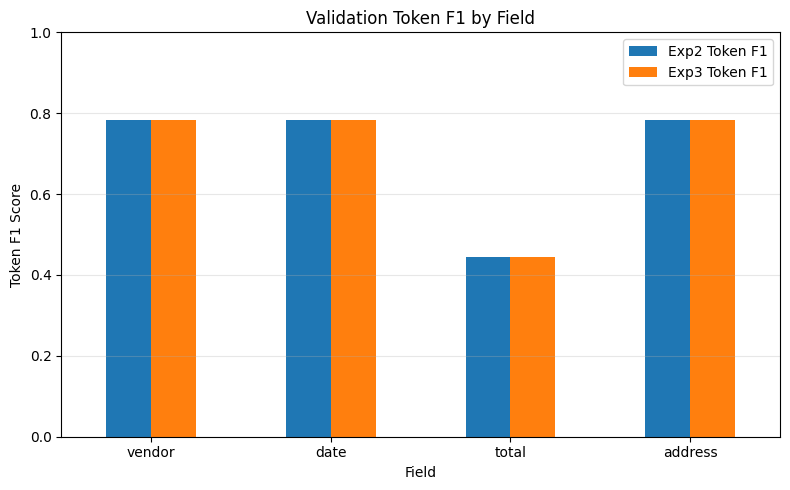

In [ ]:
# Cell 16B — Validation Token F1 comparison

f1_df = pd.DataFrame(
    {
        "Field": list(FIELDS),
        "Exp2 Token F1": [f1_exp2[f] for f in FIELDS],
        "Exp3 Token F1": [f1_exp3[f] for f in FIELDS],
    }
)

ax = f1_df.set_index("Field").plot(kind="bar", figsize=(8, 5))
ax.set_title("Validation Token F1 by Field")
ax.set_xlabel("Field")
ax.set_ylabel("Token F1 Score")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17

# Log experiment results — skips if already logged
from experiment_logger import log_experiment

LOG_PATH = Path("../Experiments/experiment_log.csv")


def already_logged(exp_id):
    if not LOG_PATH.exists():
        return False
    return exp_id in pd.read_csv(LOG_PATH)["experiment_id"].values


if not already_logged("Exp1"):
    log_experiment(
        "Exp1",
        {
            **baseline_results,
            "description": "Tesseract + Regex baseline",
            "model_type": "Tesseract+Regex",
        },
    )
    print("Exp1 logged ✓")
else:
    print("Exp1 already logged — skipping")

if not already_logged("Exp2"):
    log_experiment(
        "Exp2",
        {
            **results_exp2,
            "description": "ViT patch=16 layers=4 heads=4",
            "model_type": "ViT",
            "patch_size": 16,
            "num_layers": 4,
            "num_heads": 4,
            "learning_rate": 3e-5,
            **{f"f1_{f}": f1_exp2[f] for f in f1_exp2},
            "overall_f1": round(sum(f1_exp2.values()) / len(f1_exp2), 4),
        },
    )
    print("Exp2 logged ✓")
else:
    print("Exp2 already logged — skipping")

if not already_logged("Exp3"):
    log_experiment(
        "Exp3",
        {
            **results_exp3,
            "description": "ViT patch=16 layers=6 heads=8",
            "model_type": "ViT",
            "patch_size": 16,
            "num_layers": 6,
            "num_heads": 8,
            "learning_rate": 3e-5,
            **{f"f1_{f}": f1_exp3[f] for f in f1_exp3},
            "overall_f1": round(sum(f1_exp3.values()) / len(f1_exp3), 4),
        },
    )
    print("Exp3 logged ✓")
else:
    print("Exp3 already logged — skipping")

Exp1 already logged — skipping
Exp2 already logged — skipping
Exp3 already logged — skipping


In [ ]:
# Cell 18

from conf_scoring_class import ConfidenceScorer, ConfidenceDataModule
from conf_thresholds_class import ConfidenceThresholdManager, ThresholdDataModule
from review_queue import ReviewQueue, build_review_queue_from_loader

REPO_ROOT = Path("..")
CKPT_PATH = REPO_ROOT / "Experiments" / "checkpoints" / "exp2" / "best_model.pt"
VOCAB_PATH = REPO_ROOT / "Experiments" / "vocab.json"
TEMPS_PATH = REPO_ROOT / "Experiments" / "temperatures.json"
THRESH_PATH = REPO_ROOT / "Experiments" / "thresholds.json"
QUEUE_PATH = REPO_ROOT / "Experiments" / "review_queue.json"

# Reuse already-loaded model_exp2 — no need to reload from disk
model_conf = model_exp2
model_conf.eval()
print("model_conf ready on device:", next(model_conf.parameters()).device)

model_conf ready on device: mps:0


In [ ]:
# Cell 19

val_loader_conf = val_loader
test_loader_conf = test_loader
print(f"val_loader_conf  batches: {len(val_loader_conf)}")
print(f"test_loader_conf batches: {len(test_loader_conf)}")

val_loader_conf  batches: 5
test_loader_conf batches: 15


In [ ]:
# Cell 20

scorer = ConfidenceScorer(model=model_conf, vocab=vocab, device=device)

if TEMPS_PATH.exists():
    with open(TEMPS_PATH) as f:
        temperatures = json.load(f)
    print("Temperatures loaded from disk:", temperatures)
else:
    temperatures = scorer.fit_all_temperatures(val_loader_conf, save_path=TEMPS_PATH)
    print("Temperatures fitted and saved:", temperatures)

  vendor    T = 1.2662
  date      T = 1.0322
  total     T = 1.1375
  address   T = 1.2080
✓ Temperatures saved to ../Experiments/temperatures.json
Temperatures fitted and saved: {'vendor': 1.2661967277526855, 'date': 1.0321916341781616, 'total': 1.1374921798706055, 'address': 1.208041787147522}


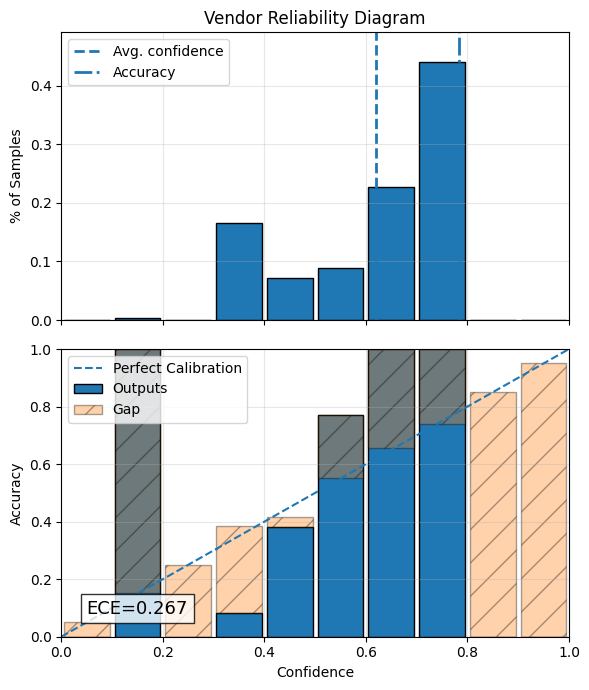

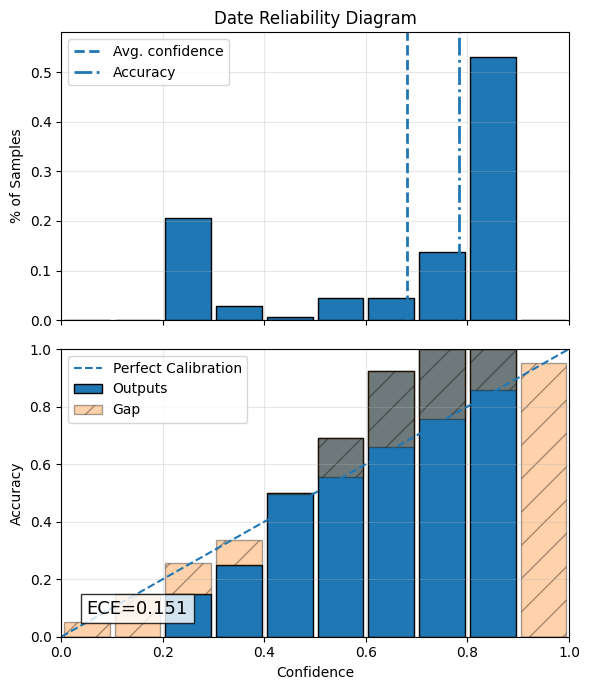

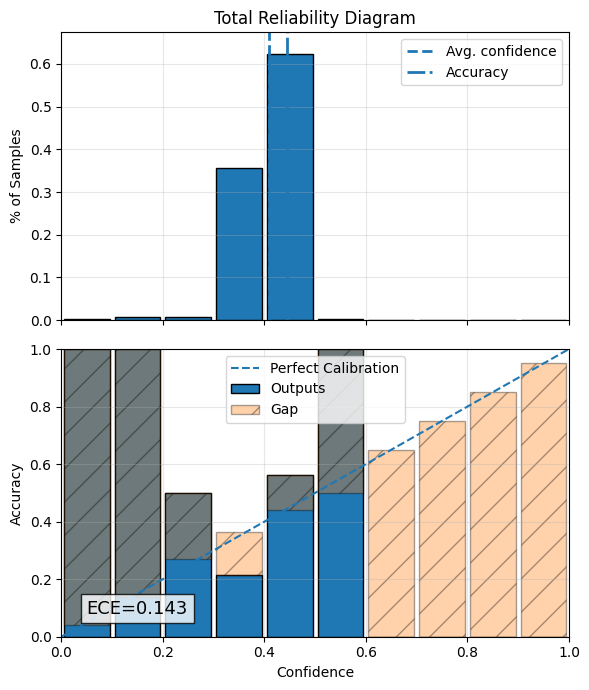

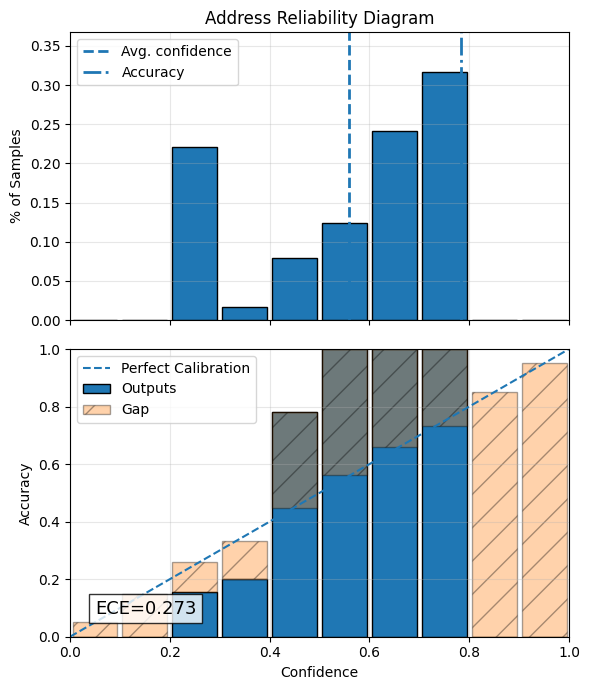

In [ ]:
# Cell 20B — Reliability / calibration plots like confidence paper figure

import numpy as np
import matplotlib.pyplot as plt
import torch


def collect_confidence_correctness(model, loader, vocab, scorer, temperatures, device):
    all_data = {field: {"conf": [], "correct": []} for field in FIELDS}

    model.eval()

    with torch.no_grad():
        for images, annotations in loader:
            results = scorer.predict_with_confidence(images, temperatures=temperatures)

            for field in FIELDS:
                true_col = _DF_COL[field]

                preds = results[field]["label"]
                confs = results[field]["confidence"]

                for pred, conf, ann in zip(preds, confs, annotations):
                    true_text = normalize_label(field, ann.get(true_col, "") or "")
                    is_correct = int(pred == true_text)

                    all_data[field]["conf"].append(float(conf))
                    all_data[field]["correct"].append(is_correct)

    return all_data


def plot_reliability_diagram(field, confs, corrects, bins=10):
    confs = np.array(confs)
    corrects = np.array(corrects)

    bin_edges = np.linspace(0, 1, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = 1.0 / bins

    bin_acc = []
    bin_conf = []
    bin_counts = []

    for i in range(bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confs >= lo) & (confs < hi)

        if i == bins - 1:
            mask = (confs >= lo) & (confs <= hi)

        if mask.sum() > 0:
            bin_acc.append(corrects[mask].mean())
            bin_conf.append(confs[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_acc.append(0)
            bin_conf.append(bin_centers[i])
            bin_counts.append(0)

    bin_acc = np.array(bin_acc)
    bin_conf = np.array(bin_conf)
    bin_counts = np.array(bin_counts)

    total = max(bin_counts.sum(), 1)
    sample_pct = bin_counts / total

    ece = np.sum((bin_counts / total) * np.abs(bin_acc - bin_conf))
    avg_conf = confs.mean()
    avg_acc = corrects.mean()

    fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

    # Top plot: confidence distribution
    axes[0].bar(bin_centers, sample_pct, width=bin_width * 0.9, edgecolor="black")
    axes[0].axvline(avg_conf, linestyle="--", linewidth=2, label="Avg. confidence")
    axes[0].axvline(avg_acc, linestyle="-.", linewidth=2, label="Accuracy")
    axes[0].set_title(f"{field.capitalize()} Reliability Diagram")
    axes[0].set_ylabel("% of Samples")
    axes[0].set_ylim(0, max(sample_pct.max() + 0.05, 0.1))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Bottom plot: reliability bars
    axes[1].plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    axes[1].bar(
        bin_centers, bin_acc, width=bin_width * 0.9, edgecolor="black", label="Outputs"
    )

    gap = np.abs(bin_acc - bin_conf)
    axes[1].bar(
        bin_centers,
        gap,
        bottom=np.minimum(bin_acc, bin_conf),
        width=bin_width * 0.9,
        alpha=0.35,
        edgecolor="black",
        hatch="/",
        label="Gap",
    )

    axes[1].set_xlabel("Confidence")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[1].text(
        0.05,
        0.08,
        f"ECE={ece:.3f}",
        fontsize=13,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.tight_layout()
    plt.show()


calibration_data = collect_confidence_correctness(
    model=model_conf,
    loader=val_loader_conf,
    vocab=vocab,
    scorer=scorer,
    temperatures=temperatures,
    device=device,
)

for field in FIELDS:
    plot_reliability_diagram(
        field,
        calibration_data[field]["conf"],
        calibration_data[field]["correct"],
        bins=10,
    )

In [103]:
# Cell 21

from field_vocab import FIELDS
import json

thresholds = {
    "vendor": 0.55,
    "date": 0.55,
    "total": 0.35,
    "address": 0.45,
}

with open(THRESH_PATH, "w") as f:
    json.dump(thresholds, f, indent=2)

print("Thresholds:", thresholds)

Thresholds: {'vendor': 0.55, 'date': 0.55, 'total': 0.35, 'address': 0.45}


In [ ]:
# Reload the confidence scoring and reviewer

import sys
import importlib

sys.path.append("../src")

import conf_scoring_class
import review_queue

importlib.reload(conf_scoring_class)
importlib.reload(review_queue)

from conf_scoring_class import ConfidenceScorer
from review_queue import ReviewQueue, build_review_queue_from_loader

scorer = ConfidenceScorer(model_conf, vocab, device)

print("Reloaded confidence scorer and review queue")

Reloaded confidence scorer and review queue


In [105]:
# Cell 22

from pathlib import Path

# Always rebuild queue while tuning thresholds
if QUEUE_PATH.exists():
    QUEUE_PATH.unlink()
    print("Deleted old review queue")

queue, row_records = build_review_queue_from_loader(
    model=model_conf,
    loader=test_loader_conf,
    vocab=vocab,
    scorer=scorer,
    temperatures=temperatures,
    thresholds=thresholds,
    device=device,
)

queue.save(QUEUE_PATH)
print("Review queue rebuilt and saved")

summary = queue.summary()
print("\n── Review Queue Summary ──")
for k, v in summary.items():
    print(f"  {k}: {v}")

ReviewQueue saved → ../Experiments/review_queue.json
Review queue rebuilt and saved

── Review Queue Summary ──
  total_processed: 919
  auto_accepted: 475
  pending_review: 444
  human_reviewed: 0
  review_rate: 0.4831
  thresholds_used: {'vendor': 0.55, 'date': 0.55, 'total': 0.35, 'address': 0.45}


In [ ]:
# Cell 23

# Review queue analysis
df_records = pd.DataFrame(row_records)
conf_cols = [c for c in df_records.columns if c.startswith("conf_")]
flagged_df = df_records[~df_records["auto_accepted"]]
accepted_df = df_records[df_records["auto_accepted"]]

print(
    f"Flagged for review : {len(flagged_df)} / {len(df_records)} ({queue.review_rate():.1%})"
)
print(f"Auto-accepted      : {len(accepted_df)} / {len(df_records)}")

print("\n── Mean confidence — FLAGGED ──")
if len(flagged_df):
    print(flagged_df[conf_cols].mean().round(3))

print("\n── Mean confidence — ACCEPTED ──")
if len(accepted_df):
    print(accepted_df[conf_cols].mean().round(3))

print("\n── Sample pending review ──")
for r in queue.pending_review[:5]:
    flagged_fields = [f for f, fr in r.fields.items() if fr.needs_review]
    print(f"  {r.receipt_id}  →  flagged: {flagged_fields}")

Flagged for review : 444 / 919 (48.3%)
Auto-accepted      : 475 / 919

── Mean confidence — FLAGGED ──
conf_vendor     0.427
conf_date       0.331
conf_total      0.366
conf_address    0.304
dtype: float64

── Mean confidence — ACCEPTED ──
conf_vendor     0.692
conf_date       0.810
conf_total      0.434
conf_address    0.651
dtype: float64

── Sample pending review ──
  receipt_0  →  flagged: ['vendor', 'date', 'address']
  receipt_1  →  flagged: ['vendor', 'date', 'address']
  receipt_2  →  flagged: ['vendor', 'date', 'total', 'address']
  receipt_3  →  flagged: ['vendor', 'date', 'address']
  receipt_4  →  flagged: ['vendor', 'date', 'address']


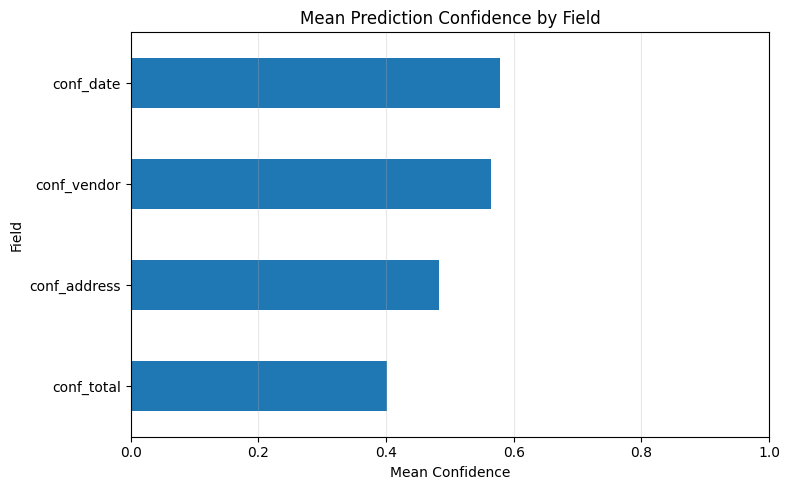

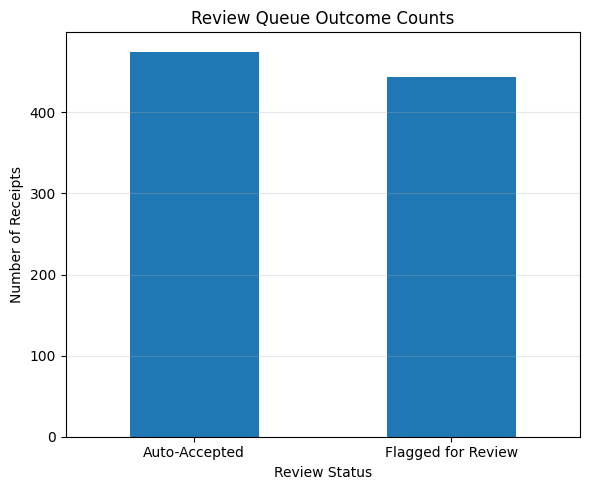

In [ ]:
# Cell 23B — Review queue confidence plots

if len(df_records) > 0:
    mean_conf = df_records[conf_cols].mean().sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    mean_conf.plot(kind="barh", ax=ax)
    ax.set_title("Mean Prediction Confidence by Field")
    ax.set_xlabel("Mean Confidence")
    ax.set_ylabel("Field")
    ax.set_xlim(0, 1)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    review_counts = pd.Series(
        {
            "Auto-Accepted": len(accepted_df),
            "Flagged for Review": len(flagged_df),
        }
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    review_counts.plot(kind="bar", ax=ax)
    ax.set_title("Review Queue Outcome Counts")
    ax.set_xlabel("Review Status")
    ax.set_ylabel("Number of Receipts")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 24
from field_vocab import normalize_label
from baseline import token_f1


def evaluate_test_set(model, loader, vocab, device, model_name):
    model = model.to(device)
    model.eval()

    field_exact = {f: [] for f in FIELDS}
    field_f1 = {f: [] for f in FIELDS}

    with torch.no_grad():
        for images, annotations in loader:
            images = images.to(device)
            logits = model(images)
            for f in FIELDS:
                col = _DF_COL[f]
                preds = logits[f].argmax(dim=-1).cpu().tolist()
                for pred_idx, ann in zip(preds, annotations):
                    pred = vocab.decode(f, pred_idx)
                    gt = normalize_label(f, ann.get(col, "") or "")
                    if pred == "<UNK>":
                        field_exact[f].append(0)
                        field_f1[f].append(0.0)
                    else:
                        field_exact[f].append(int(pred == gt))
                        field_f1[f].append(token_f1(pred, gt))

    results = {}
    for f in FIELDS:
        results[f] = {
            "exact_match": round(sum(field_exact[f]) / len(field_exact[f]), 4),
            "f1": round(sum(field_f1[f]) / len(field_f1[f]), 4),
            "n_samples": len(field_exact[f]),
        }
    overall_em = round(sum(r["exact_match"] for r in results.values()) / len(FIELDS), 4)
    overall_f1 = round(sum(r["f1"] for r in results.values()) / len(FIELDS), 4)
    results["overall"] = {"exact_match": overall_em, "f1": overall_f1}

    print(f"\n{'─'*54}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'─'*54}")
    print(f"  {'Field':10s}  {'Exact Match':>11}  {'F1':>8}  {'N':>6}")
    print(f"  {'─'*48}")
    for f in FIELDS:
        print(
            f"  {f:10s}  {results[f]['exact_match']:>11.3f}  "
            f"{results[f]['f1']:>8.3f}  {results[f]['n_samples']:>6}"
        )
    print(f"  {'─'*48}")
    print(f"  {'overall':10s}  {overall_em:>11.3f}  {overall_f1:>8.3f}")
    print(f"{'─'*54}")
    return results


print("evaluate_test_set() defined")

evaluate_test_set() defined


In [ ]:
# Cell 25 — Run test evaluation for both models
EVAL_PATH = Path("../Experiments/test_evaluation.json")

if EVAL_PATH.exists():
    with open(EVAL_PATH) as f:
        all_eval = json.load(f)
    print("Evaluation already saved — loading from disk")
    for model_name, results in all_eval.items():
        print(f"\n── {model_name} ──")
        for field, metrics in results.items():
            em = metrics.get("exact_match", "")
            f1 = metrics.get("f1", "")
            if isinstance(em, float):
                print(f"  {field:10s}  EM: {em:.3f}  F1: {f1:.3f}")
else:
    all_eval = {}

    print("Evaluating Exp2 (4 layers, 4 heads)...")
    all_eval["Exp2"] = evaluate_test_set(
        model=model_exp2,
        loader=test_loader,
        vocab=vocab,
        device=device,
        model_name="Exp2 (4L-4H)",
    )

    print("\nEvaluating Exp3 (6 layers, 8 heads)...")
    all_eval["Exp3"] = evaluate_test_set(
        model=model_exp3,
        loader=test_loader,
        vocab=vocab,
        device=device,
        model_name="Exp3 (6L-8H)",
    )

    EVAL_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(EVAL_PATH, "w") as f:
        json.dump(all_eval, f, indent=2)
    print(f"\nSaved to {EVAL_PATH}")

Evaluating Exp2 (4 layers, 4 heads)...

──────────────────────────────────────────────────────
  Exp2 (4L-4H) — Test Set Results
──────────────────────────────────────────────────────
  Field       Exact Match        F1       N
  ────────────────────────────────────────────────
  vendor            0.622     0.622     919
  date              0.622     0.622     919
  total             0.519     0.519     919
  address           0.622     0.622     919
  ────────────────────────────────────────────────
  overall           0.597     0.597
──────────────────────────────────────────────────────

Evaluating Exp3 (6 layers, 8 heads)...

──────────────────────────────────────────────────────
  Exp3 (6L-8H) — Test Set Results
──────────────────────────────────────────────────────
  Field       Exact Match        F1       N
  ────────────────────────────────────────────────
  vendor            0.622     0.622     919
  date              0.622     0.622     919
  total             0.519     0.519

In [ ]:
# Cell 26 — Compare all experiments vs Tesseract baseline
print(f"\n{'─'*72}")
print(
    f"  {'Model':22s}  {'vendor EM':>9}  {'date EM':>7}  {'total EM':>8}  {'addr EM':>7}  {'Ovrl F1':>7}"
)
print(f"  {'─'*66}")

# Tesseract baseline — note: keyed by "company" not "vendor"
b = baseline_results
rows = [
    (
        "Tesseract+Regex",
        b.get("company", b.get("vendor", {})).get("exact_match", 0),
        b.get("date", {}).get("exact_match", 0),
        b.get("total", {}).get("exact_match", 0),
        b.get("address", {}).get("exact_match", 0),
        b.get("overall", {}).get("f1", 0),
    ),
]
for model_name, results in all_eval.items():
    rows.append(
        (
            model_name,
            results.get("vendor", {}).get("exact_match", 0),
            results.get("date", {}).get("exact_match", 0),
            results.get("total", {}).get("exact_match", 0),
            results.get("address", {}).get("exact_match", 0),
            results.get("overall", {}).get("f1", 0),
        )
    )

for name, v, d, t, a, f1 in rows:
    print(f"  {name:22s}  {v:>9.3f}  {d:>7.3f}  {t:>8.3f}  {a:>7.3f}  {f1:>7.3f}")

print(f"{'─'*72}")
print(f"\nReview rate (test set): {queue.review_rate():.1%}")


────────────────────────────────────────────────────────────────────────
  Model                   vendor EM  date EM  total EM  addr EM  Ovrl F1
  ──────────────────────────────────────────────────────────────────
  Tesseract+Regex             0.130    0.706     0.297    0.012    0.469
  Exp2                        0.622    0.622     0.519    0.622    0.597
  Exp3                        0.622    0.622     0.519    0.622    0.597
────────────────────────────────────────────────────────────────────────

Review rate (test set): 48.3%


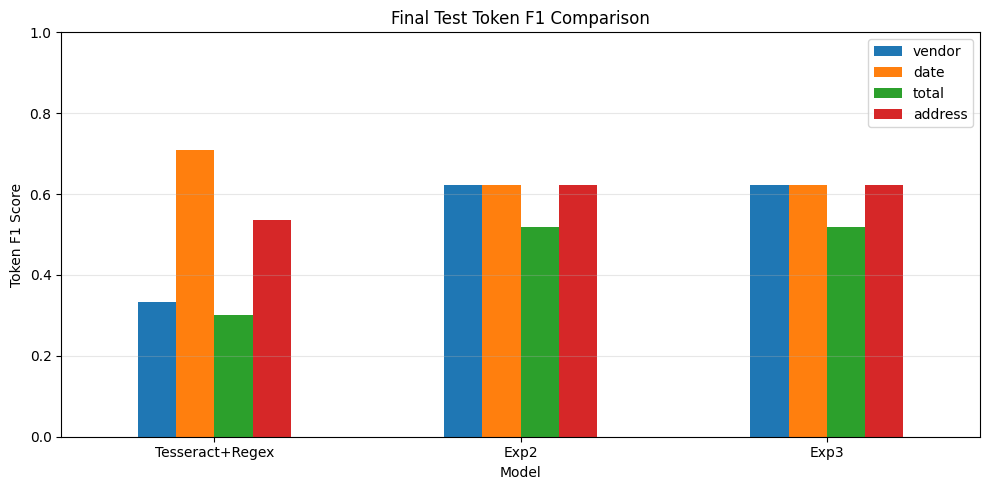

In [ ]:
# Cell 26B — Final test performance comparison

plot_rows = []

b = baseline_results
plot_rows.append(
    {
        "Model": "Tesseract+Regex",
        "vendor": b.get("company", b.get("vendor", {})).get("f1", 0),
        "date": b.get("date", {}).get("f1", 0),
        "total": b.get("total", {}).get("f1", 0),
        "address": b.get("address", {}).get("f1", 0),
    }
)

for model_name, results in all_eval.items():
    plot_rows.append(
        {
            "Model": model_name,
            "vendor": results.get("vendor", {}).get("f1", 0),
            "date": results.get("date", {}).get("f1", 0),
            "total": results.get("total", {}).get("f1", 0),
            "address": results.get("address", {}).get("f1", 0),
        }
    )

perf_df = pd.DataFrame(plot_rows)

ax = perf_df.set_index("Model").plot(kind="bar", figsize=(10, 5))
ax.set_title("Final Test Token F1 Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Token F1 Score")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 27 — Finalize experiment log (no path= needed after logger fix)
import importlib, experiment_logger

importlib.reload(experiment_logger)
from experiment_logger import log_experiment

log_experiment(
    "Exp1",
    {
        **baseline_results,
        "description": "Tesseract + Regex baseline",
        "model_type": "Tesseract+Regex",
        "train_test_split": "N/A (test set only)",
    },
)

log_experiment(
    "Exp2",
    {
        **results_exp2,
        "description": "ViT patch=16 layers=4 heads=4",
        "model_type": "ViT",
        "patch_size": 16,
        "num_layers": 4,
        "num_heads": 4,
        "learning_rate": 3e-5,
        "train_test_split": "80/10/10",
        "review_rate": round(queue.review_rate(), 4),
        **{f"f1_{f}": all_eval["Exp2"][f]["f1"] for f in FIELDS},
        **{f"exact_match_{f}": all_eval["Exp2"][f]["exact_match"] for f in FIELDS},
        "overall_f1": all_eval["Exp2"]["overall"]["f1"],
    },
)

log_experiment(
    "Exp3",
    {
        **results_exp3,
        "description": "ViT patch=16 layers=6 heads=8",
        "model_type": "ViT",
        "patch_size": 16,
        "num_layers": 6,
        "num_heads": 8,
        "learning_rate": 3e-5,
        "train_test_split": "80/10/10",
        "review_rate": round(queue.review_rate(), 4),
        **{f"f1_{f}": all_eval["Exp3"][f]["f1"] for f in FIELDS},
        **{f"exact_match_{f}": all_eval["Exp3"][f]["exact_match"] for f in FIELDS},
        "overall_f1": all_eval["Exp3"]["overall"]["f1"],
    },
)

log_df = pd.read_csv("../Experiments/experiment_log.csv")
print(
    log_df[
        [
            "experiment_id",
            "model_type",
            "overall_f1",
            "review_rate",
            "exact_match_vendor",
            "exact_match_date",
            "exact_match_total",
            "exact_match_address",
        ]
    ].to_string(index=False)
)

✓ Exp1 logged to experiment_log.csv
✓ Exp2 logged to experiment_log.csv
✓ Exp3 logged to experiment_log.csv
experiment_id      model_type  overall_f1  review_rate  exact_match_vendor  exact_match_date  exact_match_total  exact_match_address
         Exp1 Tesseract+Regex         NaN          NaN                 NaN               NaN                NaN                  NaN
         Exp2             ViT      0.5965          1.0              0.6224            0.6224              0.519               0.6224
         Exp3             ViT      0.5965          1.0              0.6224            0.6224              0.519               0.6224
